# Net2Brain - semNN (adapted to run on NSD shared)


## Installation (if not already installed)

Same as before - install from `main`, not `CCN23` (that branch no longer exists).


In [1]:
# !pip install -U git+https://github.com/cvai-roig-lab/Net2Brain
# !pip install nilearn==0.9.2
# !pip install scipy pandas numpy torch matplotlib


## 0. Setup - download NSD shared, fix Windows `unzip` issue, build `paths`

Net2Brain's built-in `DatasetAlgonauts_NSD_Shared(...).load_dataset()` shells out to
a system `unzip` binary, which doesn't exist on Windows by default
(`FileNotFoundError: [WinError 2]`). We download with the library's own logic but
extract with Python's `zipfile` instead.

The archive also extracts with **one extra nested folder**
(`Algonauts23_shared_Net2Brain/Algonauts23_shared_Net2Brain/...`) - `root` below
accounts for that. If your archive doesn't have the extra nesting, drop the second
`dataset_name` join.


In [2]:
import os, glob, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.spatial.distance import squareform

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

base_path = r"C:\Users\662\Unravelling-Brain-Func-LAION\Sem"
SUBJ = "01"

dataset_name = "Algonauts23_shared_Net2Brain"
zip_path = os.path.join(base_path, f"{dataset_name}.zip")
dataset_folder = os.path.join(base_path, dataset_name)

if not os.path.exists(dataset_folder):
    print("zip size (MB):", os.path.getsize(zip_path) / 1e6)
    os.makedirs(dataset_folder, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(dataset_folder)
else:
    print(f"{dataset_folder} already exists, skipping extraction")

nested = os.path.join(dataset_folder, dataset_name)
root = nested if os.path.isdir(nested) else dataset_folder
print("root:", root)
print("root contents:", os.listdir(root))

SUBJ_KEY = f"subj{SUBJ}"

paths = {
    "root":        root,
    "images":      os.path.join(root, "images"),
    "metadata":    os.path.join(root, "metadata_shared.csv"),
    "coco_csv":    os.path.join(root, "coco.csv"),
    "coco_images": os.path.join(root, "coco_images"),
    "coco_masks":  os.path.join(root, "coco_masks"),
}
for s in range(1, 9):
    subj = f"subj0{s}"
    paths[subj]              = os.path.join(root, subj)
    paths[f"{subj}_fmri"]    = os.path.join(root, subj, "fmri")
    paths[f"{subj}_rois"]    = os.path.join(root, subj, "rois")
    paths[f"{subj}_rdms"]    = os.path.join(root, subj, "rdms")
    paths[f"{subj}_metadata"] = os.path.join(root, subj, "metadata_shared.csv")

for k in [SUBJ_KEY, f"{SUBJ_KEY}_fmri", f"{SUBJ_KEY}_rois", f"{SUBJ_KEY}_rdms", f"{SUBJ_KEY}_metadata", "images"]:
    print(k, "->", paths[k], "->", os.path.exists(paths[k]))


device: cpu
C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts23_shared_Net2Brain already exists, skipping extraction
root: C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts23_shared_Net2Brain\Algonauts23_shared_Net2Brain
root contents: ['Algonauts23_shared_subset_Net2Brain.md', 'captions_train2017.json', 'captions_val2017.json', 'coco.csv', 'images', 'instances_train2017.json', 'instances_val2017.json', 'metadata_shared.csv', 'subj01', 'subj02', 'subj03', 'subj04', 'subj05', 'subj06', 'subj07', 'subj08']
subj01 -> C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts23_shared_Net2Brain\Algonauts23_shared_Net2Brain\subj01 -> True
subj01_fmri -> C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts23_shared_Net2Brain\Algonauts23_shared_Net2Brain\subj01\fmri -> True
subj01_rois -> C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts23_shared_Net2Brain\Algonauts23_shared_Net2Brain\subj01\rois -> True
subj01_rdms -> C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts2

### Stimulus order

`RSA`/`VPA` in Net2Brain compare model RDMs and brain RDMs **positionally** - they do
**not** align by `stimuli_name`. So the order in which we hand images to
`FeatureExtractor` must match the row order of `fmri` / `rois` / `rdms` exactly.

`subj0X/metadata_shared.csv` (inside the subject folder, not the root one) has an
`fmri_row` column that gives this order explicitly, plus a ready `filename` column -
no need to reconstruct filenames from `nsd_id`.

We also check whether this order happens to already match the natural sort order
`FeatureExtractor` will use on the image folder. If it doesn't, we copy the images
into a re-numbered folder so the two sides are guaranteed to line up.


In [4]:
import re

meta_subj = pd.read_csv(paths[f"{SUBJ_KEY}_metadata"])
meta_subj = meta_subj.sort_values("fmri_row").reset_index(drop=True)

assert meta_subj["fmri_row"].notna().all() and meta_subj["fmri_row"].is_unique, \
    "fmri_row must contain unique, non-null brain-row IDs"
assert meta_subj["filename"].notna().all() and meta_subj["filename"].is_unique, \
    "filename must contain unique, non-null stimulus names"

stim_names = meta_subj["filename"].tolist()
n_images = len(stim_names)
print("n_images:", n_images)

def natural_key(s):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)]

order_matches = sorted(stim_names, key=natural_key) == stim_names
print("FeatureExtractor natural-sort order matches brain-RDM order:", order_matches)

if order_matches:
    IMAGES_DIR_FOR_EXTRACTION = paths["images"]
else:
    import shutil
    reordered_dir = Path(f"images_reordered_{SUBJ_KEY}")
    reordered_dir.mkdir(exist_ok=True)
    if len(list(reordered_dir.glob("*.png"))) != n_images:
        for i, fname in enumerate(stim_names):
            src = os.path.join(paths["images"], fname)
            dst = reordered_dir / f"{i:04d}.png"
            if not dst.exists():
                shutil.copy(src, dst)
    IMAGES_DIR_FOR_EXTRACTION = str(reordered_dir)

print("Using images from:", IMAGES_DIR_FOR_EXTRACTION)


n_images: 872
FeatureExtractor natural-sort order matches brain-RDM order: True
Using images from: C:\Users\662\Unravelling-Brain-Func-LAION\Sem\Algonauts23_shared_Net2Brain\Algonauts23_shared_Net2Brain\images


## 1. Feature extraction - stimuli, NN, saved features (`.npz`)

Same three Taskonomy model groups as before, now pointed at
`IMAGES_DIR_FOR_EXTRACTION` instead of the old `sml_stim`.


In [5]:
from net2brain.feature_extraction import FeatureExtractor

model_groups = {
    'Sem': ['class_object'],
    '2D':  ['segment_unsup2d'],
    '3D':  ['reshading'],
}

def check_free_space(path, min_gb=5):
    usage = shutil = __import__('shutil').disk_usage(Path(path).anchor or '/')
    free_gb = usage.free / (1024 ** 3)
    if free_gb < min_gb:
        raise OSError(f"Only {free_gb:.1f} GB free near {path}. Need >= {min_gb} GB.")
    return free_gb

def extract_features(model_name, layers='top_level', min_free_gb=5):
    """Extract features for one Taskonomy model, save to sml_feats_<model>,
    and return (feature_path, resolved_layer_names)."""
    fx = FeatureExtractor(model=model_name, netset='Taskonomy', device=device)
    check_free_space(IMAGES_DIR_FOR_EXTRACTION, min_gb=min_free_gb)

    ft_path = f'sml_feats_{model_name}'
    fx.extract(data_path=IMAGES_DIR_FOR_EXTRACTION, save_path=ft_path, layers_to_extract=layers)

    resolved_layers = sorted(
        f.stem.replace('consolidated_', '')
        for f in Path(ft_path).glob('consolidated_*.npz')
    )
    print(f'{model_name}: extracted layers -> {resolved_layers}')
    return ft_path, resolved_layers

feature_paths = {}
model_layers = {}

for group_name, models in model_groups.items():
    for model_name in models:
        ft_path, layers = extract_features(model_name)
        feature_paths[model_name] = ft_path
        model_layers[model_name] = layers

print('\nAll extracted models:', list(feature_paths.keys()))


Processing files: 100%|██████████| 872/872 [04:19<00:00,  3.37it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [02:22<00:00,  6.12it/s]


class_object: extracted layers -> ['bn1', 'compress1', 'compress_bn', 'conv1', 'groupnorm', 'layer1', 'layer2', 'layer3', 'layer4', 'maxpool', 'relu', 'relu1']


Processing files: 100%|██████████| 872/872 [07:10<00:00,  2.03it/s, subfiles=1/1]


...

segment_unsup2d: extracted layers -> ['bn1', 'compress1', 'compress_bn', 'conv1', 'groupnorm', 'layer1', 'layer2', 'layer3', 'layer4', 'maxpool', 'relu', 'relu1']


Processing files: 100%|██████████| 872/872 [04:17<00:00,  3.39it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [01:47<00:00,  8.12it/s]


reshading: extracted layers -> ['bn1', 'compress1', 'compress_bn', 'conv1', 'groupnorm', 'layer1', 'layer2', 'layer3', 'layer4', 'maxpool', 'relu', 'relu1']

All extracted models: ['class_object', 'segment_unsup2d', 'reshading']


## 2. Build model RDMs (per model, per layer)

Unchanged from the original pipeline.


In [6]:
from net2brain.rdm_creation import RDMCreator

def make_model_rdms(feature_path, save_path):
    creator = RDMCreator(verbose=True, device=device)
    return creator.create_rdms(feature_path=feature_path, save_path=save_path,
                                save_format='npz')

model_rdm_dirs = {}
for model_name, ft_path in feature_paths.items():
    rdm_dir = make_model_rdms(ft_path, f'rdms_{model_name}')
    model_rdm_dirs[model_name] = Path(rdm_dir)

for model_name, rdm_dir in model_rdm_dirs.items():
    files = sorted(rdm_dir.glob('RDM_*.npz'))
    print(model_name, '->', rdm_dir, '(', len(files), 'layer RDMs )')


C:\Users\662\AppData\Roaming\Python\Python312\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/12 [00:00<?, ?it/s]

Creating RDMs:   0%|          | 0/12 [00:00<?, ?it/s]

Creating RDMs:   0%|          | 0/12 [00:00<?, ?it/s]

class_object -> rdms_class_object ( 12 layer RDMs )
segment_unsup2d -> rdms_segment_unsup2d ( 12 layer RDMs )
reshading -> rdms_reshading ( 12 layer RDMs )


## 3. Brain RDMs per ROI - convert NSD-shared `.npy` to Net2Brain's `.npz` format

NSD shared ships brain RDMs **already computed**, in `subj0X/rdms/*.npy` - no need to
build them from raw responses like the old `fmri_to_rdm()` did.

Two format differences to fix:
- Each file is a **condensed** (upper-triangle) vector, not a square matrix.
- Each file is a bare `.npy` array. `RSA`/`VPA` call `.keys()` on whatever
  `np.load()` returns, which only works on `.npz` - a plain `.npy` has no `.keys()`
  and will raise `AttributeError`. So we wrap each one into an `.npz` with `rdm` and
  `stimuli_name` keys, the format `RDMCreator` itself produces.

(Verified: `squareform(rdms/<roi>.npy)` matches `1 - corrcoef(rois/<roi>.npy)` to
~1e-8 - the two folders are internally consistent.)


In [9]:
def convert_npy_rdms_to_npz(rdms_dir, stim_names, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)
    roi_rdm_paths = {}
    for f in sorted(Path(rdms_dir).glob('*.npy')):
        vec = np.load(f)
        rdm = squareform(vec)
        roi_name = f.stem
        out_path = out_dir / f'{roi_name}.npz'
        np.savez(out_path, rdm=rdm[np.newaxis, :, :], stimuli_name=np.array(stim_names))
        roi_rdm_paths[roi_name] = str(out_path)
    return roi_rdm_paths

roi_rdm_dir = Path(f'roi_rdms_{SUBJ_KEY}')
roi_rdm_paths = convert_npy_rdms_to_npz(paths[f'{SUBJ_KEY}_rdms'], stim_names, roi_rdm_dir)
print('ROIs found:', list(roi_rdm_paths.keys()))


ROIs found: ['EBA_lh_subj01', 'EBA_rh_subj01', 'FBA-1_lh_subj01', 'FBA-1_rh_subj01', 'FBA-2_rh_subj01', 'FFA-1_lh_subj01', 'FFA-1_rh_subj01', 'FFA-2_rh_subj01', 'hV4_lh_subj01', 'hV4_rh_subj01', 'mfs-words_lh_subj01', 'OFA_lh_subj01', 'OFA_rh_subj01', 'OPA_lh_subj01', 'OPA_rh_subj01', 'OWFA_lh_subj01', 'OWFA_rh_subj01', 'PPA_lh_subj01', 'PPA_rh_subj01', 'RSC_lh_subj01', 'RSC_rh_subj01', 'V1d_lh_subj01', 'V1d_rh_subj01', 'V1v_lh_subj01', 'V1v_rh_subj01', 'V2d_lh_subj01', 'V2d_rh_subj01', 'V2v_lh_subj01', 'V2v_rh_subj01', 'V3d_lh_subj01', 'V3d_rh_subj01', 'V3v_lh_subj01', 'V3v_rh_subj01', 'VWFA-1_lh_subj01', 'VWFA-1_rh_subj01', 'VWFA-2_lh_subj01', 'VWFA-2_rh_subj01']


## 4. RSA: compare each model's per-layer RDMs to each brain ROI RDM

Unchanged - `RSA` just needs a folder of `.npz` files, which `roi_rdm_dir` now is.


In [11]:
from net2brain.evaluations.rsa import RSA

rsa_results = {}
for model_name, rdm_dir in model_rdm_dirs.items():
    evaluation = RSA(str(rdm_dir), str(roi_rdm_dir), model_name=model_name)
    df = evaluation.evaluate()
    rsa_results[model_name] = df
    print(f'\n{model_name}:')
    result_columns = ['ROI', 'Layer', 'R', 'R2', 'Significance']
    display(df[[column for column in result_columns if column in df.columns]])


C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: invalid value encountered in multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\net2brain\evaluations\rsa.py:240: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(corr_list)  # standard error of mean
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:122


class_object:


,ROI,Layer,R2,Significance
0,(0) EBA_lh_subj01,(0) RDM_bn1.npz,0.003468,NaN
1,(0) EBA_lh_subj01,(1) RDM_compress1.npz,0.004274,NaN
2,(0) EBA_lh_subj01,(2) RDM_compress_bn.npz,0.005148,NaN
3,(0) EBA_lh_subj01,(3) RDM_conv1.npz,0.00173,NaN
4,(0) EBA_lh_subj01,(4) RDM_groupnorm.npz,0.004154,NaN
...,...,...,...,...
439,(36) VWFA-2_rh_subj01,(7) RDM_layer3.npz,0.000411,NaN
440,(36) VWFA-2_rh_subj01,(8) RDM_layer4.npz,0.000491,NaN
441,(36) VWFA-2_rh_subj01,(9) RDM_maxpool.npz,0.000914,NaN
442,(36) VWFA-2_rh_subj01,(10) RDM_relu1.npz,0.000535,NaN


C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: invalid value encountered in multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\net2brain\evaluations\rsa.py:240: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(corr_list)  # standard error of mean
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:122


segment_unsup2d:


,ROI,Layer,R2,Significance
0,(0) EBA_lh_subj01,(0) RDM_bn1.npz,0.001965,NaN
1,(0) EBA_lh_subj01,(1) RDM_compress1.npz,0.00003,NaN
2,(0) EBA_lh_subj01,(2) RDM_compress_bn.npz,0.000028,NaN
3,(0) EBA_lh_subj01,(3) RDM_conv1.npz,0.001874,NaN
4,(0) EBA_lh_subj01,(4) RDM_groupnorm.npz,0.000089,NaN
...,...,...,...,...
439,(36) VWFA-2_rh_subj01,(7) RDM_layer3.npz,0.000202,NaN
440,(36) VWFA-2_rh_subj01,(8) RDM_layer4.npz,0.000007,NaN
441,(36) VWFA-2_rh_subj01,(9) RDM_maxpool.npz,0.000796,NaN
442,(36) VWFA-2_rh_subj01,(10) RDM_relu1.npz,0.000061,NaN


C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: invalid value encountered in multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\net2brain\evaluations\rsa.py:240: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(corr_list)  # standard error of mean
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:1227: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
C:\Users\662\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:122


reshading:


,ROI,Layer,R2,Significance
0,(0) EBA_lh_subj01,(0) RDM_bn1.npz,0.002775,NaN
1,(0) EBA_lh_subj01,(1) RDM_compress1.npz,0.000737,NaN
2,(0) EBA_lh_subj01,(2) RDM_compress_bn.npz,0.000377,NaN
3,(0) EBA_lh_subj01,(3) RDM_conv1.npz,0.001919,NaN
4,(0) EBA_lh_subj01,(4) RDM_groupnorm.npz,0.001491,NaN
...,...,...,...,...
439,(36) VWFA-2_rh_subj01,(7) RDM_layer3.npz,0.000201,NaN
440,(36) VWFA-2_rh_subj01,(8) RDM_layer4.npz,0.000268,NaN
441,(36) VWFA-2_rh_subj01,(9) RDM_maxpool.npz,0.000683,NaN
442,(36) VWFA-2_rh_subj01,(10) RDM_relu1.npz,0.000161,NaN


## 5. Layer-wise RSA plot (extraction order preserved)

ROI names here are NSD-shared functional ROIs (`EBA_lh_subj01`, `FFA-1_rh_subj01`,
`hV4_lh_subj01`, ...), not `V1/V2/V3/PPA`. Pick from `roi_rdm_paths.keys()` below and
edit `roi_for_single_plot` to whichever ROI you actually want.


Available ROIs: ['EBA_lh_subj01', 'EBA_rh_subj01', 'FBA-1_lh_subj01', 'FBA-1_rh_subj01', 'FBA-2_rh_subj01', 'FFA-1_lh_subj01', 'FFA-1_rh_subj01', 'FFA-2_rh_subj01', 'hV4_lh_subj01', 'hV4_rh_subj01', 'mfs-words_lh_subj01', 'OFA_lh_subj01', 'OFA_rh_subj01', 'OPA_lh_subj01', 'OPA_rh_subj01', 'OWFA_lh_subj01', 'OWFA_rh_subj01', 'PPA_lh_subj01', 'PPA_rh_subj01', 'RSC_lh_subj01', 'RSC_rh_subj01', 'V1d_lh_subj01', 'V1d_rh_subj01', 'V1v_lh_subj01', 'V1v_rh_subj01', 'V2d_lh_subj01', 'V2d_rh_subj01', 'V2v_lh_subj01', 'V2v_rh_subj01', 'V3d_lh_subj01', 'V3d_rh_subj01', 'V3v_lh_subj01', 'V3v_rh_subj01', 'VWFA-1_lh_subj01', 'VWFA-1_rh_subj01', 'VWFA-2_lh_subj01', 'VWFA-2_rh_subj01']


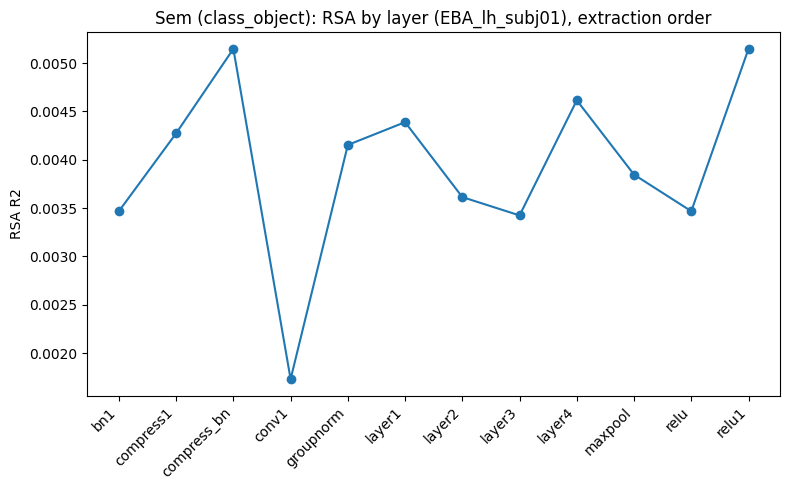

In [15]:
def roi_label(df, roi_name):
    """RSA prefixes ROI labels with '(i) '; find the full label for roi_name."""
    matches = [r for r in df['ROI'].unique() if roi_name in r]
    if not matches:
        raise KeyError(f'{roi_name!r} not found among ROI labels: {df["ROI"].unique()}')
    return matches[0]

def ordered_layer_plot(df, roi_name, layer_order, ax=None, label=None):
    """Plot RSA R or R2 values in feature-extraction order."""
    full_roi = roi_label(df, roi_name)
    sub = df[df['ROI'] == full_roi].copy()
    value_col = 'R' if 'R' in sub.columns else 'R2'
    if value_col not in sub.columns:
        raise KeyError(f'RSA results need an R or R2 column; found {list(sub.columns)}')

    sub['layer_name'] = (
        sub['Layer'].astype(str)
        .str.replace(r'^\(\d+\)\s*RDM_', '', regex=True)
        .str.removesuffix('.npz')
    )
    sub['layer_name'] = pd.Categorical(
        sub['layer_name'], categories=layer_order, ordered=True
    )
    sub = sub.sort_values('layer_name')

    values = pd.to_numeric(sub[value_col], errors='coerce').to_numpy(dtype=float)
    ax = ax or plt.gca()
    x = np.arange(len(sub))
    ax.plot(x, values, marker='o', label=label or roi_name)

    if 'SEM' in sub.columns:
        sem = pd.to_numeric(sub['SEM'], errors='coerce').to_numpy(dtype=float)
        if np.isfinite(sem).any():
            ax.fill_between(x, values - sem, values + sem, alpha=0.2)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['layer_name'], rotation=45, ha='right')
    ax.set_ylabel(f'RSA {value_col}')
    return ax

available_rois = list(roi_rdm_paths.keys())
print('Available ROIs:', available_rois)

roi_for_single_plot = available_rois[0]

fig, ax = plt.subplots(figsize=(8, 5))
ordered_layer_plot(rsa_results['class_object'], roi_for_single_plot,
                   model_layers['class_object'], ax=ax)
ax.set_title(f'Sem (class_object): RSA by layer ({roi_for_single_plot}), extraction order')
plt.tight_layout()
plt.show()


### Layer-wise similarity across a few ROIs

The old cell hardcoded `V1/V2/V3/PPA`, which don't exist in NSD shared's ROI set.
This version just plots the first few available ROIs - edit the `roi_subset` list to
whichever specific ROIs you want to compare (see `available_rois` printed above).


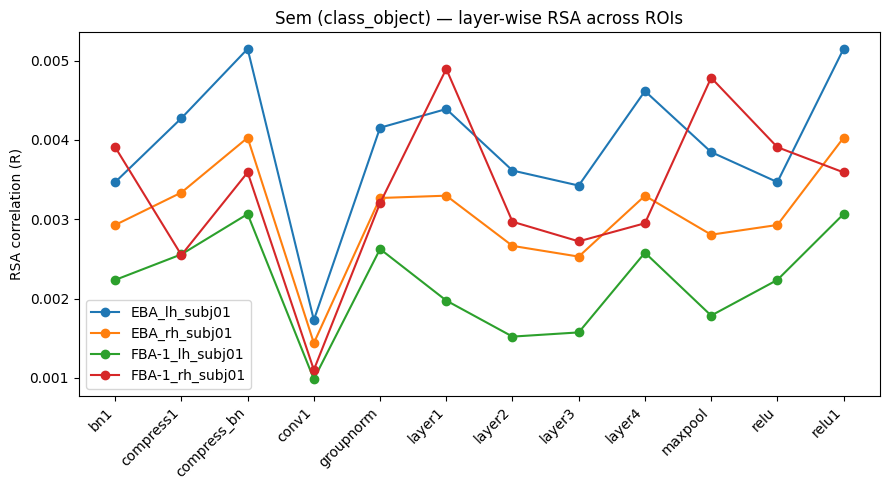

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

roi_subset = available_rois[:4]

for roi in roi_subset:
    ordered_layer_plot(rsa_results['class_object'], roi, model_layers['class_object'],
                        ax=ax, label=roi)

ax.legend()
ax.set_ylabel('RSA correlation (R)')
ax.set_title('Sem (class_object) - layer-wise RSA across ROIs')
plt.tight_layout()
plt.show()


## 6. Aggregate model-type RDMs and Variance Partitioning Analysis (VPA)

Same logic as before. `roi_rdm_paths` (built in step 3) now supplies the brain side
directly - no more manual `roi_rdm_paths` construction from raw `.npy` responses.


In [ ]:
def group_rdm_paths(group_name):
    rdm_paths = []
    for model_name in model_groups[group_name]:
        rdm_dir = model_rdm_dirs[model_name]
        rdm_paths.extend(str(p) for p in sorted(rdm_dir.glob('RDM_*.npz')))
    return rdm_paths

variable_names = ['2D', '3D', 'Sem']
raw_group_paths = [group_rdm_paths(name) for name in variable_names]

def load_and_average_group(paths_list):
    vecs = []
    for p in paths_list:
        with np.load(p) as data:
            rdm = np.asarray(data['rdm'])
        if rdm.ndim == 2 and rdm.shape[0] == rdm.shape[1]:
            rdm = squareform(rdm, checks=False)
        vecs.append(rdm)
    return np.mean(np.array(vecs), axis=0)

averaged_group_vecs = [load_and_average_group(p) for p in raw_group_paths]

avg_dir = Path(f'avg_group_rdms_{SUBJ_KEY}')
avg_dir.mkdir(exist_ok=True)
independent_variables = []
for name, vec in zip(variable_names, averaged_group_vecs):
    out_path = avg_dir / f'{name}_avg.npz'
    np.savez(out_path, rdm=vec, stimuli_name=np.array(stim_names))
    independent_variables.append([str(out_path)])

uvp_rows = []
results_rows = []
for roi_name, rdm_path in vpa_roi_rdm_paths.items():
    with np.load(rdm_path) as data:
        dep_vec = np.squeeze(np.asarray(data['rdm']))  # (1, N) -> (N,)

    vpa_eval = VPA([rdm_path], independent_variables, variable_names)
    vpa_eval.average_models = False

    result = vpa_eval.VPA_3(dep_vec)

    for key, value in result.items():
        results_rows.append({
            'ROI': roi_name,
            'Variable': key,
            'Values': np.array([value]),
            'Significance': np.array([np.nan]),
        })

df_vpa_all = pd.DataFrame(results_rows)
print(df_vpa_all.shape)
display(df_vpa_all.head(20))

(518, 4)


,ROI,Variable,Values,Significance
0,EBA_lh_subj01,R1,[0.0006416993122649872],[nan]
1,EBA_lh_subj01,R2,[0.0026602835643880773],[nan]
2,EBA_lh_subj01,R3,[0.007070935141653356],[nan]
3,EBA_lh_subj01,R12,[0.0027424731544087866],[nan]
4,EBA_lh_subj01,R13,[0.007292607595209333],[nan]
5,EBA_lh_subj01,R23,[0.007208404602210061],[nan]
6,EBA_lh_subj01,R123,[0.0073194041327123704],[nan]
7,EBA_lh_subj01,y123,[0.0004488367991906106],[nan]
8,EBA_lh_subj01,y12,[0.00011067292305366738],[nan]
9,EBA_lh_subj01,y13,[-2.8809940481600016e-05],[nan]


EBA_lh_subj01


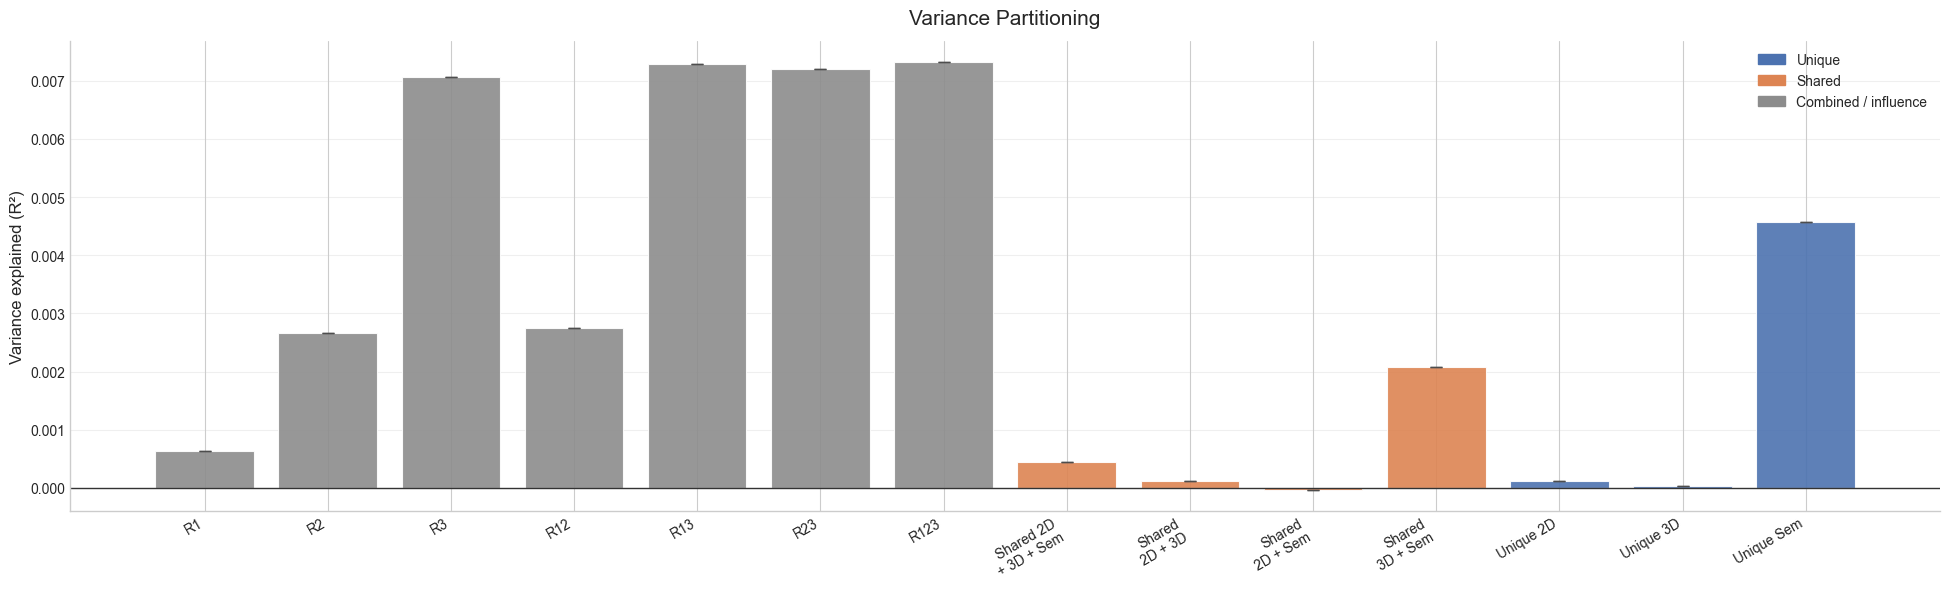

EBA_rh_subj01


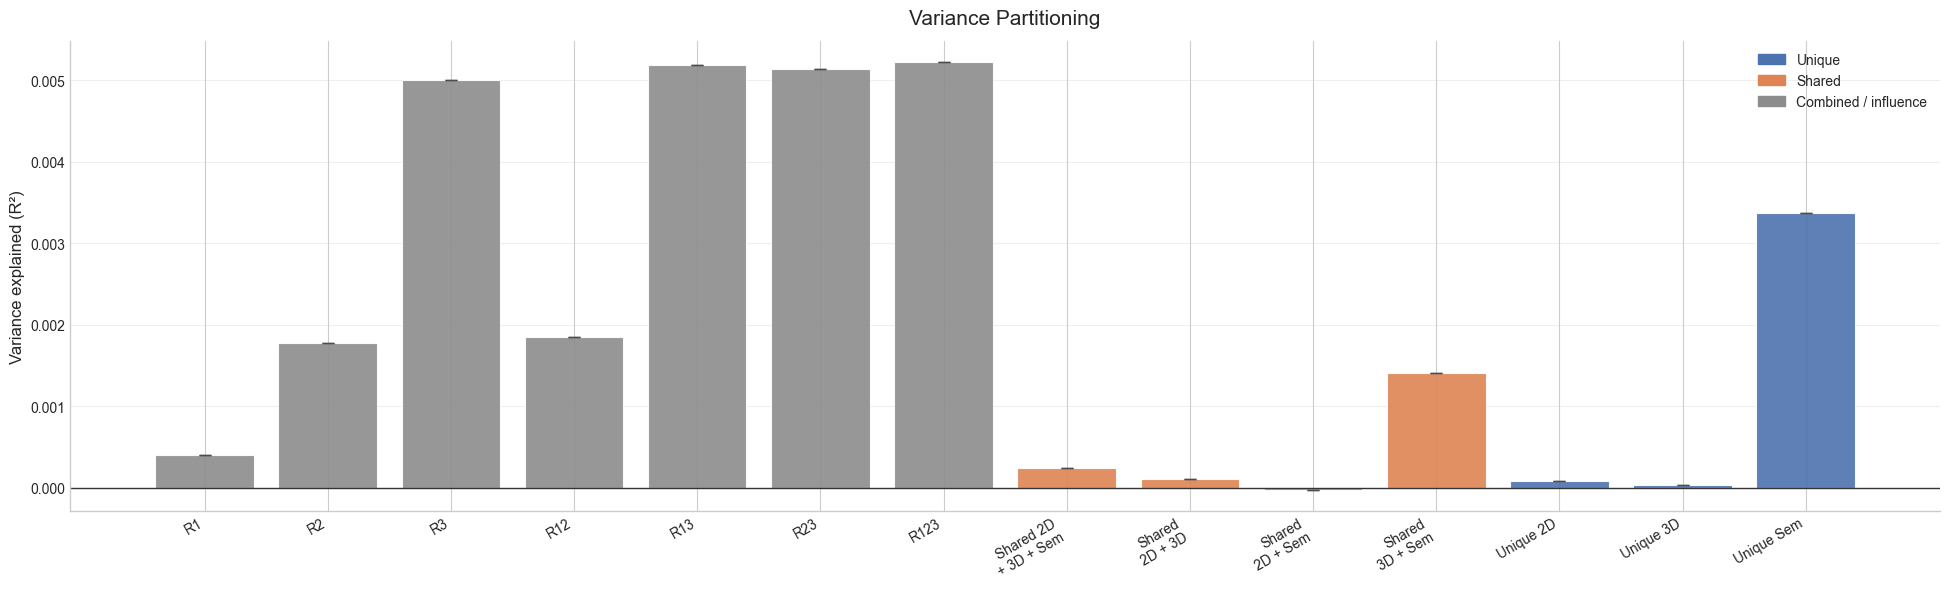

FBA-1_lh_subj01


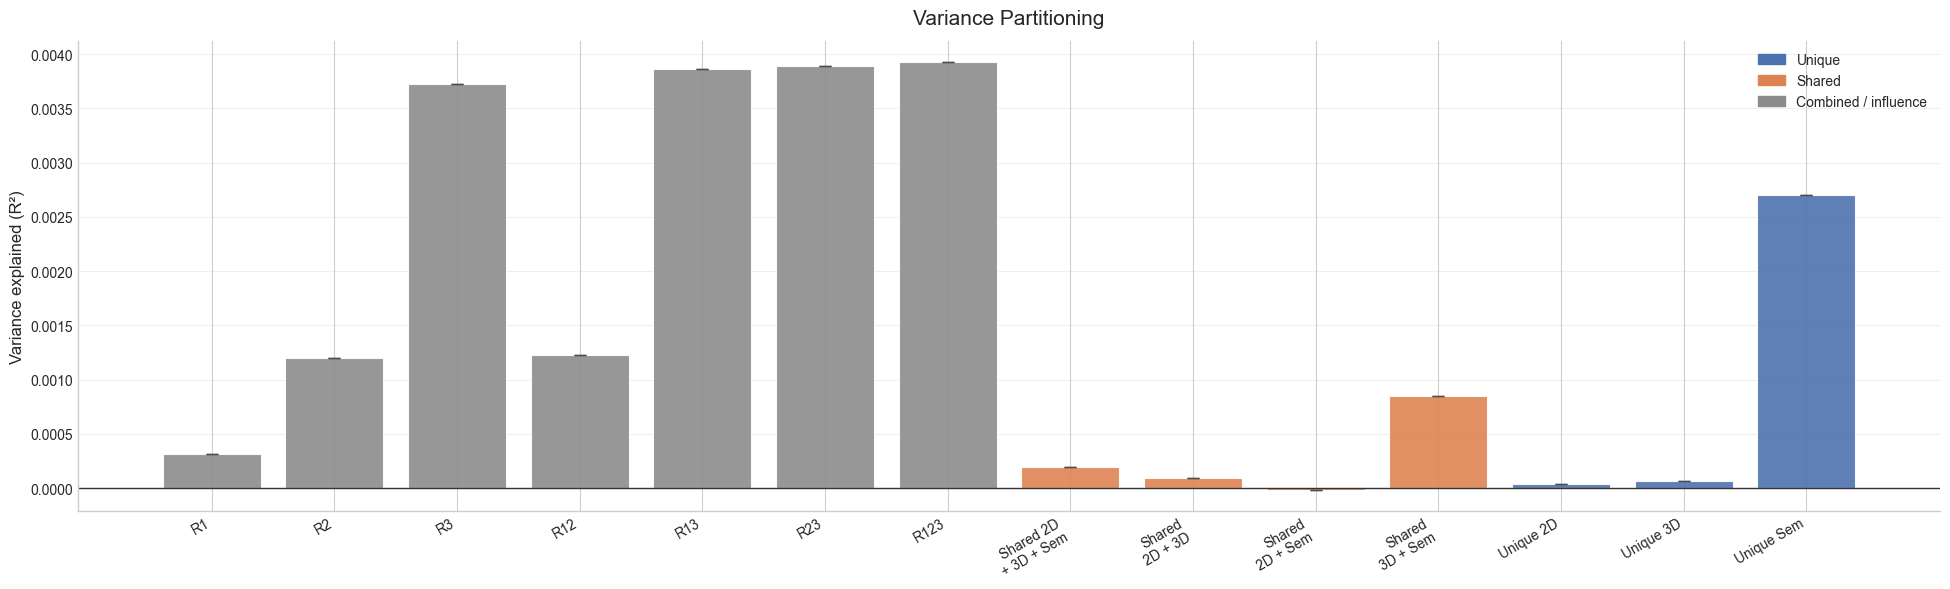

In [26]:
roi_plot_subset = available_rois[:3]

component_descriptions = {
    'y1': 'Unique 2D',
    'y2': 'Unique 3D',
    'y3': 'Unique Sem',
    'y12': 'Shared 2D + 3D',
    'y13': 'Shared 2D + Sem',
    'y23': 'Shared 3D + Sem',
    'y123': 'Shared 2D + 3D + Sem',
}

for roi in roi_plot_subset:
    print(roi)
    df_roi = df_vpa_all[df_vpa_all['ROI'] == roi].copy()
    df_roi['Description'] = df_roi['Variable'].map(
        component_descriptions
    ).fillna(df_roi['Variable'].astype(str))
    plotter = Plotting(df_roi)
    plotter.plotting_components()
    plt.show()


## 7. Summarize & plot UVP results across ROIs

Unchanged - works off `df_vpa_all`/`roi_rdm_paths`, both already generic.


In [27]:
df_plot = df_vpa_all.query("Variable in ['y1', 'y2', 'y3', 'y123']").copy()

df_plot['Mean'] = df_plot['Values'].apply(lambda x: float(np.mean(np.asarray(x))))
df_plot['SEM'] = df_plot['Values'].apply(
    lambda x: np.std(np.asarray(x), ddof=1) / np.sqrt(len(np.asarray(x)))
    if len(np.asarray(x)) > 1 else 0.0
)

name_map = {'y1': '2D', 'y2': '3D', 'y3': 'Sem', 'y123': 'Shared'}
df_plot['Component'] = df_plot['Variable'].map(name_map)

display(df_plot[['ROI', 'Component', 'Mean', 'SEM']])


,ROI,Component,Mean,SEM
7,EBA_lh_subj01,Shared,4.488368e-04,0.0
11,EBA_lh_subj01,2D,1.109995e-04,0.0
12,EBA_lh_subj01,3D,2.679654e-05,0.0
13,EBA_lh_subj01,Sem,4.576931e-03,0.0
21,EBA_rh_subj01,Shared,2.375909e-04,0.0
...,...,...,...,...
503,VWFA-2_lh_subj01,Sem,3.820257e-04,0.0
511,VWFA-2_rh_subj01,Shared,3.232062e-04,0.0
515,VWFA-2_rh_subj01,2D,2.433982e-06,0.0
516,VWFA-2_rh_subj01,3D,7.054609e-07,0.0


In [28]:
summary = df_plot.pivot(index='ROI', columns='Component', values='Mean')

summary['R2_full'] = summary[['2D', '3D', 'Sem', 'Shared']].sum(axis=1)
summary = summary[['R2_full', '2D', '3D', 'Sem', 'Shared']]

display(summary)

summary.to_csv(f'UVP_summary_ROIs_{SUBJ_KEY}.csv')
print(f'Saved: UVP_summary_ROIs_{SUBJ_KEY}.csv')

df_vpa_all.to_csv(f'UVP_all_ROIs_{SUBJ_KEY}.csv', index=False)
print(f'Saved: UVP_all_ROIs_{SUBJ_KEY}.csv')


Component,R2_full,2D,3D,Sem,Shared
ROI,,,,,
EBA_lh_subj01,0.005164,1.109995e-04,2.679654e-05,0.004577,0.000449
EBA_rh_subj01,0.003731,8.870178e-05,3.067797e-05,0.003374,0.000238
FBA-1_lh_subj01,0.002998,3.985320e-05,6.346409e-05,0.002703,0.000191
FBA-1_rh_subj01,0.004859,2.660738e-07,1.372215e-04,0.003961,0.000760
FBA-2_rh_subj01,0.002394,4.604623e-05,1.044270e-06,0.002021,0.000326
FFA-1_lh_subj01,0.003652,2.077556e-05,7.155534e-05,0.003156,0.000404
FFA-1_rh_subj01,0.001101,1.416193e-05,8.474124e-06,0.000956,0.000123
FFA-2_rh_subj01,0.002931,2.479728e-05,3.592205e-06,0.002385,0.000518
OFA_lh_subj01,0.002112,4.352750e-08,3.125729e-05,0.001647,0.000434


Saved: UVP_summary_ROIs_subj01.csv
Saved: UVP_all_ROIs_subj01.csv


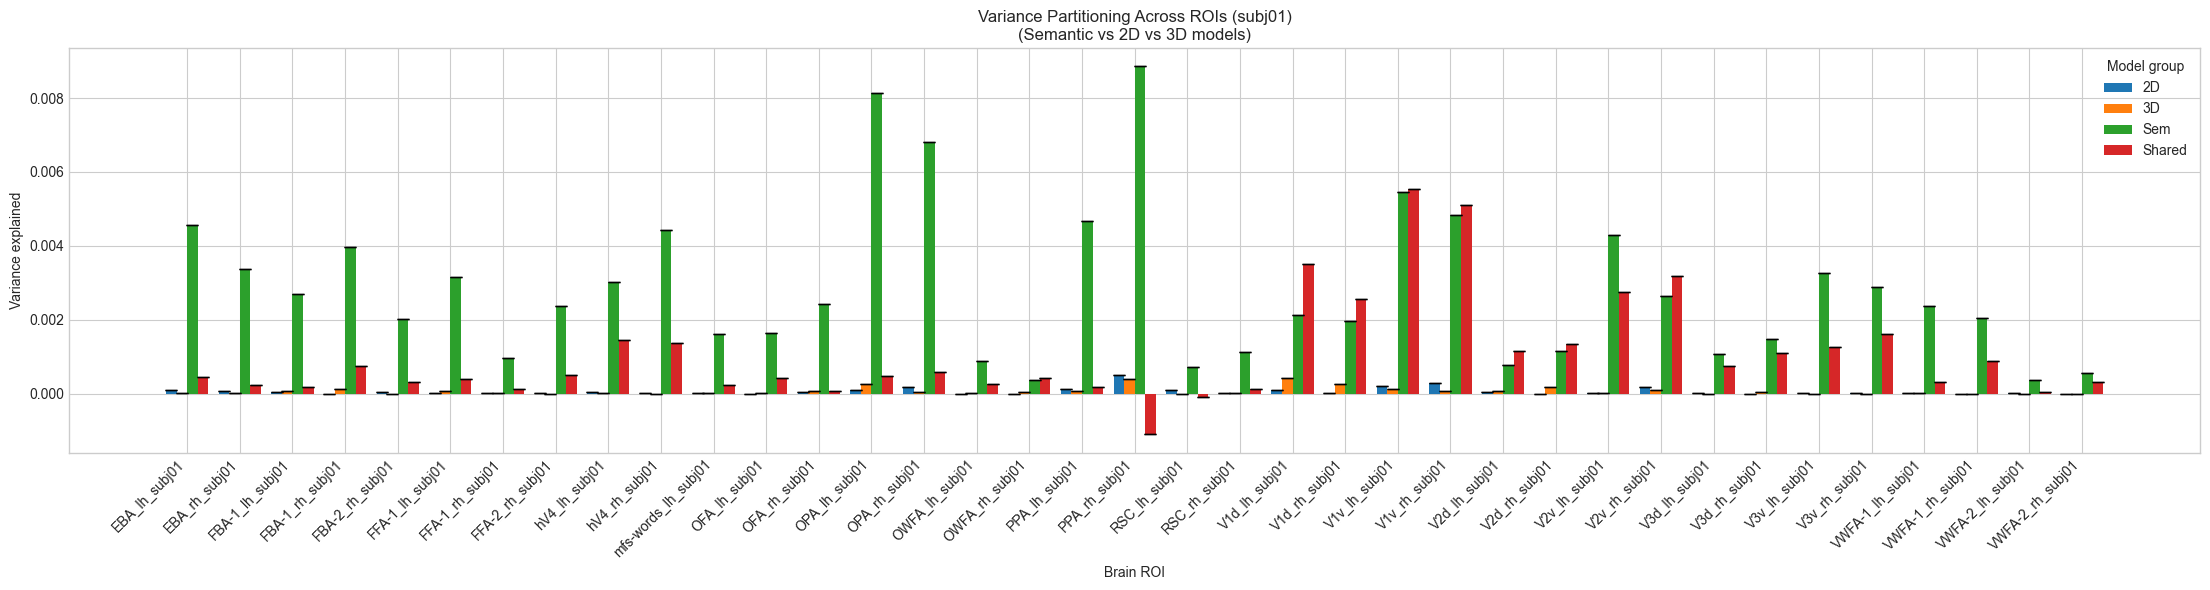

In [29]:
components = ['2D', '3D', 'Sem', 'Shared']
rois = list(df_plot['ROI'].unique())

x = np.arange(len(rois))
width = 0.2

fig, ax = plt.subplots(figsize=(max(10, len(rois) * 0.6), 6))

for i, comp in enumerate(components):
    subset = df_plot[df_plot['Component'] == comp]
    means, sems = [], []
    for roi in rois:
        row = subset[subset['ROI'] == roi].iloc[0]
        means.append(row['Mean'])
        sems.append(row['SEM'])

    ax.bar(x + (i - 1.5) * width, means, width, label=comp, yerr=sems, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(rois, rotation=45, ha='right')
ax.set_ylabel('Variance explained')
ax.set_xlabel('Brain ROI')
ax.set_title(f'Variance Partitioning Across ROIs ({SUBJ_KEY})\n(Semantic vs 2D vs 3D models)')
ax.legend(title='Model group')

plt.tight_layout()
plt.savefig(f'UVP_all_ROIs_{SUBJ_KEY}.png', dpi=300, bbox_inches='tight')
plt.show()
